In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\SURYA\Downloads\house_prices_practice.csv")

In [3]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [4]:
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [5]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [6]:
df=pd.get_dummies(df,drop_first=True)

In [7]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [8]:
x=df.drop(['SalePrice'],axis=1)
y=df['SalePrice']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.9724366615461971
Mean Squared Error: 156388404.64634562
Mean Absolute Error: 10431.822888363304
Root Mean Squared Error: 12505.53496042235


In [10]:
from sklearn.tree import DecisionTreeRegressor
tree_model=DecisionTreeRegressor(random_state=42)
tree_model.fit(x_train,y_train)
y_pred_tree=tree_model.predict(x_test)
print("R2 Score:",r2_score(y_test,y_pred_tree)) 
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_tree))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred_tree))
print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_pred_tree))

R2 Score: 0.5886438828013874
Mean Squared Error: 2333945397.0
Mean Absolute Error: 38828.46666666667
Root Mean Squared Error: 48310.924199398214


In [11]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_pred))

R2 Score: 0.8642260096662696
Mean Squared Error: 770352175.457575
Mean Absolute Error: 20910.577500000003
Root Mean Squared Error: 27755.21888686117


In [12]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor(n_estimators=300,random_state=42,learning_rate=0.05,max_depth=7,subsample=0.8,colsample_bytree=0.8)
xgb_model.fit(x_train,y_train)
y_pred_xgb=xgb_model.predict(x_test)
print("R2 Score:",r2_score(y_test,y_pred_xgb))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_xgb))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred_xgb))
print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_pred_xgb))

R2 Score: 0.8724761605262756
Mean Squared Error: 723542656.0
Mean Absolute Error: 20278.8203125
Root Mean Squared Error: 26898.748046875


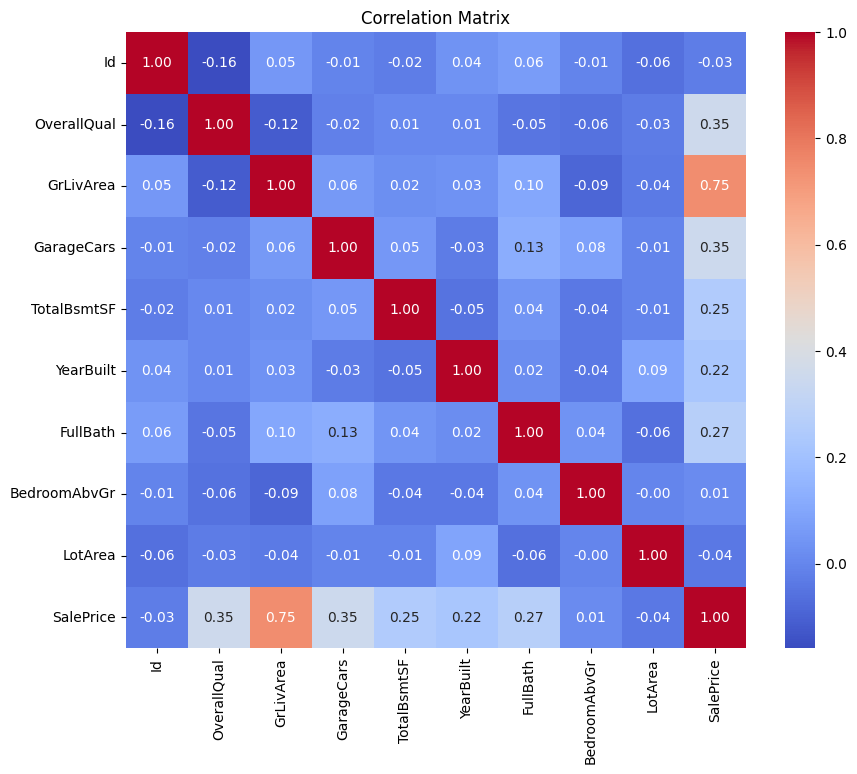

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
import joblib

# Save the trained ML model
joblib.dump(model, "house_price_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [16]:
import joblib

# Save model
joblib.dump(model, "house_price_model.joblib")

# Save feature columns after get_dummies()
model_columns = x.columns.tolist()
joblib.dump(model_columns, "house_model_columns.joblib")

print("Model and columns saved successfully!")

Model and columns saved successfully!
